In [22]:
 # import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import numpy as np
import joblib

import sklearn
print(sklearn.__version__)


1.6.1


In [23]:
# Load and display data
def load_data(url):
  df = pd.read_csv(url)
  return df

In [24]:
def display_categorical(df):
  # display number of unique entries for categorical variables
  display(df['product_category'].value_counts())
  display(df['social_media_platform'].value_counts())
  display(df['review_sentiment'].value_counts())

In [25]:
def data_preprocessing(df, le):
  # create numerical values to represent the date
  df['purchase_date'] = pd.to_datetime(df['purchase_date'])
  df['year'] = df['purchase_date'].dt.year
  df['month']= df['purchase_date'].dt.month
  df['day'] = df['purchase_date'].dt.day
  df['weekday'] = df['purchase_date'].dt.day_of_week
  df['isweekend'] = (df['weekday'] >= 5).astype(int)

  # drop date column
  df.drop(columns='purchase_date', inplace=True)

  # drop id and year columns because they are not relevant to model
  df = df.drop(['customer_id','transaction_id', 'year'], axis=1)

  # get list of numerical columns - return
  numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('isweekend')

  # Label encoding for product category columns
  
  df['product_category'] = le.fit_transform(df['product_category'])
  # Ordinal encoding for review sentiment column
  sentiment_mapping = {'Negative':0, 'Neutral': 1, 'Positive': 2}
  df['review_sentiment'] = df['review_sentiment']. map(sentiment_mapping)

  # one hot encoding for social media platforms
  df = pd.get_dummies(df, columns=['social_media_platform'], dtype=int)
  
  # print label mapping
  print("Books = 0\nClothing = 1\nElectronics = 2\nGroceries = 3\nSports = 4")

  return df, numeric_cols

In [26]:
# prep data for machine learning
def prep_data(df):
  X = df.drop('product_category', axis=1)
  y = df['product_category']
  X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
  print(f'X_train shape : {X_train.shape}\nX_test shape : {X_test.shape}\ny_train shape : {y_train.shape}\ny_test shape : {y_test.shape}\n')
  return X,y,X_train,X_test,y_train,y_test



In [27]:
# vanilla random forest model
from sklearn.metrics import log_loss
def normal_rf(X_train,X_test,y_train,y_test):
  rf_1 = RandomForestClassifier(class_weight='balanced')
  rf_1.fit(X_train, y_train)
  y_pred = rf_1.predict(X_test)
  y_proba = rf_1.predict_proba(X_test)
  loss = log_loss(y_test, y_proba)
  print(f"Random forest log loss:{loss}\n")
  print("Books = 0\nClothing = 1\nElectronics = 2\nGroceries = 3\nSports = 4")
  print(classification_report(y_test, y_pred))

  return rf_1



In [28]:
# random forest with GridSearchCV
def grid_search_rf(X, X_train, X_test, y_train, y_test):
  rf_2 = RandomForestClassifier(random_state=42)

  param_grid = {
      'n_estimators': [50, 100],               # Number of trees
      'max_depth': [None, 4, 10, 20],             # Depth of trees
      'min_samples_split': [2, 5],             # Min samples to split a node
      'min_samples_leaf': [1, 2],              # Min samples at a leaf
      'max_features': ['sqrt', 'log2'],        # Feature selection method
      'bootstrap': [True],
      'class_weight':['balanced']
  }

  rf_grid = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=2,
    verbose=0
  )
  rf_grid.fit(X_train, y_train)

  print("Best Parameters:", rf_grid.best_params_)
  best_model = rf_grid.best_estimator_

  importances = best_model.feature_importances_
  features = X.columns

  feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
  feat_df.sort_values(by='Importance', ascending=False, inplace=True)

  # Plot
  plt.figure(figsize=(10, 6))
  plt.barh(feat_df['Feature'], feat_df['Importance'])
  plt.xlabel("Feature Importance")
  plt.title("Random Forest Feature Importances")
  plt.gca().invert_yaxis()
  plt.show()

  y_pred = best_model.predict(X_test)
  y_proba = best_model.predict_proba(X_test)
  loss = log_loss(y_test, y_proba)
  print(f"Random forest with grid search log loss:{loss}\n")
  print(classification_report(y_test, y_pred))
  return rf_grid

In [29]:
# random forest with RandomizedSearchCV
def randomized_search(X, X_train, X_test, y_train, y_test):
  rf3 = RandomForestClassifier(class_weight='balanced', random_state=42)

  # Define parameter distribution
  param_dist = {
      'n_estimators': [50, 100, 200, 300],
      'max_depth': [None, 5, 10, 20, 30],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': ['sqrt', 'log2'],
      'bootstrap': [True]
  }

  # Randomized Search
  rf_random = RandomizedSearchCV(
      estimator=rf3,
      param_distributions=param_dist,
      n_iter=50,               # Try 20 random combinations
      cv=3,                    # 3-fold cross-validation
      scoring='accuracy',
      random_state=42,
      n_jobs=-1,
      verbose=0
  )

  # Fit
  rf_random.fit(X_train, y_train)

  # Best model
  best_rf = rf_random.best_estimator_
  print("Best parameters found:", rf_random.best_params_)

  # Evaluate
  y_pred = best_rf.predict(X_test)
  print("=== RandomizedSearch RF Classification")
  print(classification_report(y_test, y_pred))

  y_proba = best_rf.predict_proba(X_test)
  loss = log_loss(y_test, y_proba)
  print(f"Random forest with randomized search log loss:{loss}\n")


  return best_rf



In [30]:
# XGBoost Model with GridSearchCV
def xg_boost_model(X, X_train, X_test, y_train, y_test):
  from xgboost import XGBClassifier
  # Define base model
  xgb_base = XGBClassifier(
      objective='multi:softmax',      # For multi-class classification
      num_class=len(set(y)),          # Number of unique classes
      use_label_encoder=False,
      eval_metric='mlogloss',
      random_state=42
  )

  # Define parameter grid
  param_grid = {
      'n_estimators': [50, 100],
      'max_depth': [3, 5, 10],
      'learning_rate': [0.01, 0.1, 0.3],
      'subsample': [0.8, 1.0],
      'colsample_bytree': [0.8, 1.0]
  }

  # GridSearchCV
  xgb_grid = GridSearchCV(
      estimator=xgb_base,
      param_grid=param_grid,
      scoring='accuracy',
      cv=3,
      n_jobs=-1,
      verbose=0
  )

  # Fit to training data
  xgb_grid.fit(X_train, y_train)

  # Best model
  best_xgb = xgb_grid.best_estimator_
  print("Best Parameters:", xgb_grid.best_params_)

  # Evaluate on test data
  y_pred_xgb = best_xgb.predict(X_test)
  print("\n=== Tuned XGBoost Classification Report ===")
  print(classification_report(y_test, y_pred_xgb))

  y_proba = best_xgb.predict_proba(X_test)  # shape: (num_samples, num_classes)
  loss = log_loss(y_test, y_proba)
  print("XGBoost Log Loss:", loss)

  return best_xgb


In [31]:
# logistic regression model
def logistic_regression_model(X, X_train, X_test, y_train, y_test, numeric_cols):
  scaler = StandardScaler()
  X_train_scaled = X_train.copy()
  X_test_scaled = X_test.copy()

  X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
  X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

  logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
  logreg.fit(X_train_scaled, y_train)

  # Step 4: Predict and evaluate
  y_pred_logreg = logreg.predict(X_test_scaled)
  print("=== Logistic Regression Classification Report ===")
  print(classification_report(y_test, y_pred_logreg))

  y_proba = logreg.predict_proba(X_test)
  loss = log_loss(y_test, y_proba)
  print("Logistic Regression Log Loss:", loss)


  return logreg

In [32]:
# save model
def save_model(model):
  joblib.dump(model, '../models/product_recommendation_model.pkl')

In [33]:
# load model
def load_model(model_path):
  loaded_model = joblib.load(model_path)
  return loaded_model

In [34]:
# make predictions
def predict(model, X_test):
  predictions = model.predict(X_test)

In [35]:
# loading data
df = load_data('../data/customer-info/merged_dataset.csv')
df.head()

,customer_id,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,190,Twitter,82,4.8,Neutral,1031,333,2024-01-31,Groceries,3.800000
1,190,Twitter,82,4.8,Neutral,1140,401,2024-05-19,Sports,4.900000
2,150,Facebook,96,1.6,Positive,1042,389,2024-02-11,Sports,3.194118
3,150,Facebook,96,1.6,Positive,1046,177,2024-02-15,Books,3.600000
4,162,Twitter,89,2.6,Positive,1079,101,2024-03-19,Books,4.200000


In [36]:
# displaying categorical columns and unique values
display_categorical(df)

product_category
Sports         59
Electronics    45
Groceries      38
Books          38
Clothing       33
Name: count, dtype: int64

social_media_platform
Twitter      56
Facebook     47
Instagram    40
LinkedIn     39
TikTok       31
Name: count, dtype: int64

review_sentiment
Positive    85
Neutral     66
Negative    62
Name: count, dtype: int64

In [37]:
# data preprocessing
le = LabelEncoder()
df, numeric_cols = data_preprocessing(df, le)
df.head()

Books = 0
Clothing = 1
Electronics = 2
Groceries = 3
Sports = 4


,engagement_score,purchase_interest_score,review_sentiment,purchase_amount,product_category,customer_rating,month,day,weekday,isweekend,social_media_platform_Facebook,social_media_platform_Instagram,social_media_platform_LinkedIn,social_media_platform_TikTok,social_media_platform_Twitter
0,82,4.8,1,333,3,3.800000,1,31,2,0,0,0,0,0,1
1,82,4.8,1,401,4,4.900000,5,19,6,1,0,0,0,0,1
2,96,1.6,2,389,4,3.194118,2,11,6,1,1,0,0,0,0
3,96,1.6,2,177,0,3.600000,2,15,3,0,1,0,0,0,0
4,89,2.6,2,101,0,4.200000,3,19,1,0,0,0,0,0,1


In [38]:
# train-test split data
X,y,X_train,X_test,y_train,y_test = prep_data(df)

X_train shape : (170, 14)
X_test shape : (43, 14)
y_train shape : (170,)
y_test shape : (43,)



In [39]:
# normal random forest model
rf_norm = normal_rf(X_train,X_test,y_train,y_test)

Random forest log loss:1.0476895207365822

Books = 0
Clothing = 1
Electronics = 2
Groceries = 3
Sports = 4
              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.80      0.67      0.73         6
           2       0.71      0.56      0.62         9
           3       0.80      1.00      0.89         8
           4       0.67      0.83      0.74        12

    accuracy                           0.74        43
   macro avg       0.76      0.74      0.74        43
weighted avg       0.75      0.74      0.74        43



Best Parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


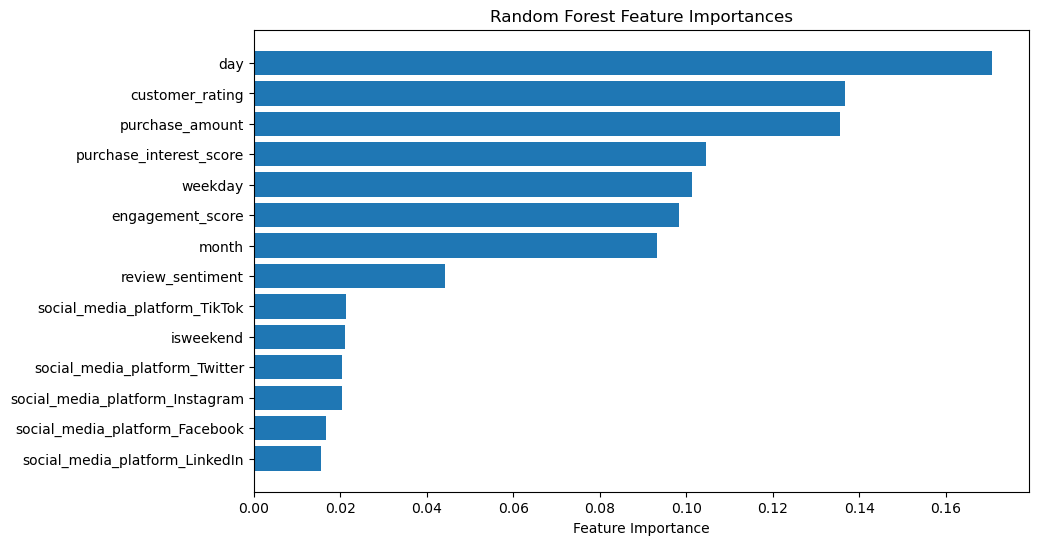

Random forest with grid search log loss:1.0515410014900024

              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.80      0.67      0.73         6
           2       0.71      0.56      0.62         9
           3       0.80      1.00      0.89         8
           4       0.60      0.75      0.67        12

    accuracy                           0.72        43
   macro avg       0.75      0.72      0.72        43
weighted avg       0.73      0.72      0.72        43



In [40]:
# random_forest with GridSearchCV
rf_grid = grid_search_rf(X,X_train,X_test,y_train,y_test)

In [41]:
# random forests with RandomizedSearchCV
rf_random = randomized_search(X,X_train,X_test,y_train,y_test)

Best parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}
=== RandomizedSearch RF Classification
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       1.00      0.67      0.80         6
           2       0.67      0.67      0.67         9
           3       0.89      1.00      0.94         8
           4       0.67      0.83      0.74        12

    accuracy                           0.79        43
   macro avg       0.84      0.78      0.80        43
weighted avg       0.82      0.79      0.79        43

Random forest with randomized search log loss:1.0399856845692281



In [ ]:
# LogisticRegression model
log_reg_model = logistic_regression_model(X,X_train,X_test,y_train,y_test, numeric_cols)

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.50      0.50      0.50         6
           2       0.29      0.44      0.35         9
           3       0.10      0.12      0.11         8
           4       0.44      0.33      0.38        12

    accuracy                           0.28        43
   macro avg       0.27      0.28      0.27        43
weighted avg       0.27      0.28      0.27        43

Logistic Regression Log Loss: 27.71982204328783


In [ ]:
# save best model
save_model(rf_random)